Required python libraries

In [39]:
import scipy as scp
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import numpy as np

---

# **PreShape Filter Analysis**

**Objective**

Study the analog PreShape circuit used in the custom fuzz pedal and understand how it modifies the guitar spectrum before the saturation stages (transistor-based and diode-based).

This notebook contains:

- theoretical analysis
- symbolic derivations
- numerical simulations
- engineering interpretation
---

# **I. Presentation**
In this notebook, we will go through the first stage of the pedal called *PreShape*. It is basically a **band-pass filter** with a fixed low-pass filter, to cut some unwanted high-end, combined with a variable high-pass filter. Since clipping stages are highly dependent on the input spectrum, this stage has a major influence on the overall character of the distortion. Even if I am not sure about how they did it, this could be seen as a simplified version of Kernom's Pretone control on the Moho pedal.  
  
Here we will try to answer this simple question :  
* How does the *PreShape* circuit alter the spectral content of the guitar signal before nonlinear clipping, and why does this change the perceived character of the fuzz?
---

# **II. Theoretical background**

---
### Design assumptions

For this first-order analysis we assume:

- ideal passive components
- infinite transistor input impedance
- linear operating region
- negligible parasitic capacitances
- Laplace notation : $j\omega = s$
---

## 1. Circuit overview  
  
The whole fuzz circuit looks like this :  
  
![title](img/Fuzz_variableHPF.png)  
  
Before doing any physical analysis, let's take a closer look at the actual *Preshape* circuit's schematic :  
  
![title](img/Preshape.png)  
  
Here we can clearly see that the circuit consists of two main parts, two filters : an HPF and a LPF.

## 2. Variable high-pass filter analysis
Let's take a closer look at the variable HPF :  
  
![title](img/Variable_HPF.png)

In [40]:
s = sp.symbols('s') # Laplace parameter
R, C = sp.symbols('R C', positive=True)
Zc = 1/(C*s) # Capacitor impedance
Zr = R # Resistor impedance

In [41]:
H_hp = (Zr)/(Zc + Zr) #Transfer function using voltage divider
H_hp

R/(R + 1/(C*s))

In [42]:
H_hp = sp.simplify(H_hp)
H_hp

C*R*s/(C*R*s + 1)

In [43]:
N, D = sp.fraction(H_hp)
N

C*R*s

In [44]:
D

C*R*s + 1

The cutoff frequency is directly linked to the pole location

In [45]:
zeros = sp.solve(N,s)
poles = sp.solve(D,s)
poles[0]

-1/(C*R)

In [46]:
zeros

[0]

The filter gives a first-order response with only one real pole.

Then we should chose numerical values for R and C to study the physical behavior of our system :

In [47]:
values = {
    R: 10e3,
    C: 47e-9
}

H_num = sp.simplify(H_hp.subs(values))
H_num

0.00047*s/(0.00047*s + 1)

In [48]:
num, den = sp.fraction(H_num)
N_poly = sp.Poly(num, s)
D_poly = sp.Poly(den, s)
N_coeffs = N_poly.all_coeffs()
D_coeffs = D_poly.all_coeffs()
N_coeffs = [float(c) for c in N_coeffs]
D_coeffs = [float(c) for c in D_coeffs]

(array([-2127.65957447+0.j]), array([0.+0.j]))

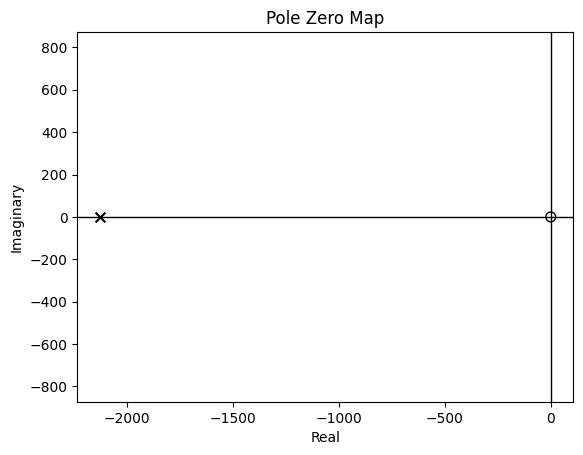

In [49]:
sys = ct.TransferFunction(
    N_coeffs,
    D_coeffs
)
ct.pzmap(sys)

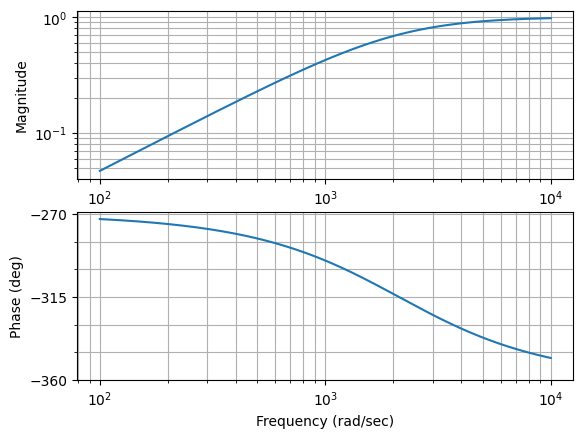

In [50]:
ct.bode_plot(sys);

Looking at the bode plot we can clearly see that the circuit is indeed behaving as a high-pass filter. Now let's see what happens when we change the resistance value by turning the potentiometer.

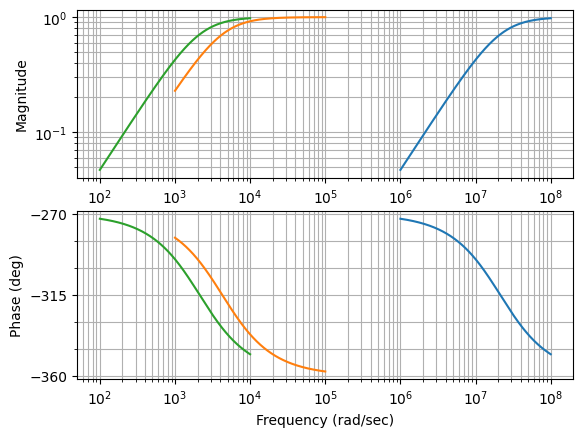

In [51]:
tab = np.linspace(1, 10e3, 3)
for i in tab : 
    values = {
        R: i,
        C: 47e-9
    }
    H_num = sp.simplify(H_hp.subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    sys = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    ct.bode(sys);

## 3. Fixed low-pass filter analysis
Regarding the LPF, it has a very basic structure :  
  
![title](img/Fix_LPF.png)

In [52]:
H_lp = sp.simplify((Zc)/(Zc + Zr)) #Transfer function using voltage divider
H_lp

1/(C*R*s + 1)

In [53]:
N, D = sp.fraction(H_lp)
D

C*R*s + 1

In [54]:
zeros = sp.solve(N,s)
poles = sp.solve(D,s)
poles[0]

-1/(C*R)

In [55]:
zeros

[]

For the fixed LPF, we should chose which component values to use for it to have the desired behavior. So we will use the same method as for the variable HPF but here the idae is not to see how the potentiometer alters th filter but rather wich resistance value is the best ofr our filter.

Define the list of resistor value below : 

In [56]:
tab = [470, 1e3, 8e3, 10e3, 50e3, 100e3]

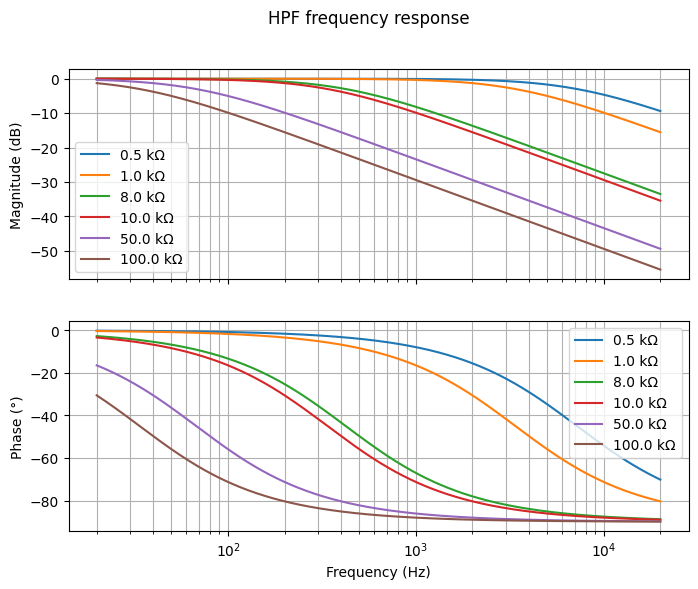

In [57]:
# human ear frequency range in rad/s
f = np.logspace(np.log10(20), np.log10(20000), 1000)
omega_range = 2*np.pi*f 

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8,6)
)

for R_value in tab:
     
    values = {
        R: R_value,
        C: 47e-9
    }
    H_num = sp.simplify(H_lp.subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    sys = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    mag, phase, omega = ct.frequency_response(sys, omega_range)
    f = omega / (2*np.pi)
    mag_db = 20*np.log10(mag)
    phase_deg = np.degrees(phase)

    ax1.semilogx(f, mag_db, label=f"{R_value/1000:.1f} kΩ")
    ax2.semilogx(f, phase_deg, label=f"{R_value/1000:.1f} kΩ")

# Display settings for a clean view   
ax1.grid(True, which="both")
ax2.grid(True, which="both")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (Hz)")
ax1.legend()
ax2.legend()
fig.suptitle("HPF frequency response")
plt.show()

## 4. Complete *Preshape* analysis
The *Preshape* is a combination of two filters that interacts with each other. We shall now study the global response of our circuit.

# **VI. Design Discussion**